In [1]:
from functions import extract_surface_lines_np
import numpy as np

In [2]:
# test function
with open('Traceparts_brep/1/1_8.brep', 'r', encoding='utf-8') as f:
    b = f.read()
    print(extract_surface_lines_np(b))

[19.84375    0.         0.        ...  0.         0.0784591 -0.9969173]


In [3]:
import os

shapes = ['0', '1', '2', '3', '4', '5']

file_list = [os.listdir('Traceparts_brep/' + shape) for shape in shapes]

X = []
y = []

for shape in shapes:
    y.append([shape]*len(os.listdir('Traceparts_brep/' + shape)))

# flatten
file_list = [item for items in file_list for item in items]
y = [item for items in y for item in items]

for i in range(0, len(file_list)):
    with open('Traceparts_brep/' + y[i] + '/' + file_list[i], 'r', encoding='utf-8') as f:
        brep_str = f.read()
        X.append(extract_surface_lines_np(brep_str))

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from numpy import float32
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

maxlen = 1024
X_pad = pad_sequences(X, maxlen=maxlen, dtype='float32', padding='post', truncating='post', value=0.0)
X_pad = X_pad[..., None]

num_outputs = len(shapes)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_arr = np.asarray(y_encoded, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(X_pad, y_arr, test_size=0.2, random_state=780)

2025-11-16 14:03:29.325368: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-16 14:03:29.354424: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-16 14:03:30.026599: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [6]:
X_train_nb = X_train.reshape(X_train.shape[0], -1)
X_test_nb  = X_test.reshape(X_test.shape[0], -1)

In [8]:
clf = GaussianNB()
clf.fit(X_train_nb, y_train)

,priors,None
,var_smoothing,1e-09


In [9]:
y_pred = clf.predict(X_test_nb)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9417


In [11]:
report = classification_report(y_test, y_pred, target_names=shapes)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.82      0.90        17
           2       0.84      0.95      0.89        22
           3       1.00      0.95      0.97        20
           4       1.00      1.00      1.00        22
           5       0.84      0.89      0.86        18

    accuracy                           0.94       120
   macro avg       0.95      0.94      0.94       120
weighted avg       0.95      0.94      0.94       120



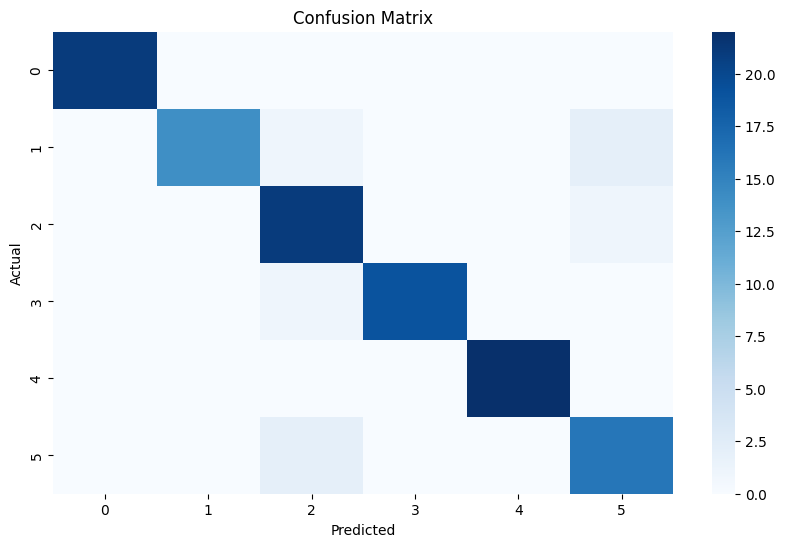

In [12]:
conf_mat = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(conf_mat, annot=False, cmap='Blues', fmt='d',
            xticklabels=shapes,
            yticklabels=shapes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()